# 딥러닝 기반 시계열 예측 모델 성능 비교 분석

이 노트북은 [딥러닝 기반 시계열 예측 모델 동향](https://ppta.or.kr/webzine/2022_11/a1.html) 기사에 소개된 주요 알고리즘들을 사용하여 업비트 비트코인(BTC/KRW) 최근 1년 데이터를 분석하고 성능을 비교합니다.

## 분석 알고리즘 리스트

1. **RNN 계열 (RNN Family)**
   - **RNN (Recurrent Neural Network)**: 기본적인 순환 신경망.
   - **LSTM (Long-Short Term Memory)**: 장기 의존성 문제를 해결한 모델.
   - **GRU (Gated Recurrent Unit)**: LSTM의 간소화 버전.

2. **ODE/CDE 기반 모델 (ODE/CDE-based Models)**
   - **Neural ODE**: 미분 방정식을 이용한 연속적 상태 변화 모델링.
   - **ODE-RNN**: GRU의 은닉 상태 변화에 ODE를 적용.

3. **Transformer 계열 (Transformer Family)**
   - **Transformer**: 어텐션 메커니즘을 시계열에 적용.
   - **Informer**: ProbSparse Attention을 통한 장기 예측 효율화.
   - **Autoformer**: Auto-correlation 기법을 도입한 시계열 분해 모델.

4. **GCN 계열 (GCN Family)**
   - **STGCN / AGCRN**: 시공간적 관계(Spatio-Temporal)를 모델링하는 그래프 신경망.

---

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import duckdb
import time
import datetime
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# CUDA 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 업비트 데이터 수집 라이브러리 (설치 확인)
try:
    import pyupbit
except ImportError:
    !pip install pyupbit
    import pyupbit

Using device: cuda


In [2]:
# 1. 데이터 불러오기 (최근 1년 Upbit BTC 데이터)
ticker = "KRW-BTC"
interval = "day"
count = 365

df = pyupbit.get_ohlcv(ticker, interval=interval, count=count)
df.reset_index(inplace=True)
df.rename(columns={'index': 'timestamp'}, inplace=True)

# 2. DuckDB 저장 및 로드
db_conn = duckdb.connect('upbit_data.db')
db_conn.execute("CREATE OR REPLACE TABLE btc_history AS SELECT * FROM df")
data_from_db = db_conn.execute("SELECT * FROM btc_history ORDER BY timestamp").df()

print(f"Data loaded from DuckDB: {len(data_from_db)} rows")
data_from_db.tail()

Data loaded from DuckDB: 365 rows


,timestamp,open,high,low,close,volume,value
360,2026-05-14 09:00:00,117854000.0,121000000.0,117325000.0,119848000.0,1626.116790,1.938759e+11
361,2026-05-15 09:00:00,119849000.0,121000000.0,117093000.0,117780000.0,1570.544690,1.866979e+11
362,2026-05-16 09:00:00,117783000.0,118050000.0,115833000.0,116697000.0,1060.997995,1.238647e+11
363,2026-05-17 09:00:00,116706000.0,117199000.0,114953000.0,115494000.0,801.524247,9.312362e+10
364,2026-05-18 09:00:00,115494000.0,115600000.0,113305000.0,113586000.0,1500.175035,1.716759e+11


In [3]:
# 데이터 전처리
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_from_db[['close']])

def create_sequences(data, seq_length):
    x = []
    y = []
    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(x), np.array(y)

SEQ_LENGTH = 10
X, y = create_sequences(scaled_data, SEQ_LENGTH)

# Train/Test 분리 (8:2)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Tensor 변환
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=16, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=1, shuffle=False)

In [4]:
# 모델 정의

class LSTMModel(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class GRUModel(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
    
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

class SimpleTransformer(nn.Module):
    def __init__(self, input_dim=1, d_model=64, nhead=4, num_layers=2):
        super(SimpleTransformer, self).__init__()
        self.encoder = nn.Linear(input_dim, d_model)
        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.transformer_encoder(x)
        return self.fc(x[:, -1, :])

# ODE-RNN 컨셉 (간소화)
class ODERNNModel(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64):
        super(ODERNNModel, self).__init__()
        self.gru_cell = nn.GRUCell(input_dim, hidden_dim)
        self.ode_func = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.fc = nn.Linear(hidden_dim, 1)
        self.hidden_dim = hidden_dim
    
    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        h = torch.zeros(batch_size, self.hidden_dim).to(device)
        for t in range(seq_len):
            h = self.gru_cell(x[:, t, :], h)
            # Simple Euler ODE step
            dt = 0.1
            h = h + self.ode_func(h) * dt
        return self.fc(h)

In [5]:
def train_model(model, loader, epochs=50):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history = []
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        history.append(epoch_loss / len(loader))
    return history

models = {
    "LSTM": LSTMModel().to(device),
    "GRU": GRUModel().to(device),
    "Transformer": SimpleTransformer().to(device),
    "ODE-RNN": ODERNNModel().to(device)
}

results = {}
for name, model in models.items():
    print(f"Training {name}...")
    history = train_model(model, train_loader, epochs=100)
    results[name] = {"model": model, "history": history}

Training LSTM...
Training GRU...
Training Transformer...
Training ODE-RNN...


In [6]:
def evaluate(model, test_loader):
    model.eval()
    preds = []
    actuals = []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            output = model(batch_x)
            preds.append(output.cpu().numpy()[0])
            actuals.append(batch_y.cpu().numpy()[0])
    
    preds = scaler.inverse_transform(np.array(preds).reshape(-1, 1))
    actuals = scaler.inverse_transform(np.array(actuals).reshape(-1, 1))
    mse = mean_squared_error(actuals, preds)
    mae = mean_absolute_error(actuals, preds)
    return preds, actuals, mse, mae

metrics = {}
for name, res in results.items():
    preds, actuals, mse, mae = evaluate(res["model"], test_loader)
    metrics[name] = {"preds": preds, "actuals": actuals, "mse": mse, "mae": mae}
    print(f"{name} - MSE: {mse:.2f}, MAE: {mae:.2f}")

LSTM - MSE: 8028760834048.00, MAE: 2397449.00
GRU - MSE: 6590657724416.00, MAE: 2195236.50
Transformer - MSE: 29257828925440.00, MAE: 5085751.00
ODE-RNN - MSE: 4818483544064.00, MAE: 1847432.62


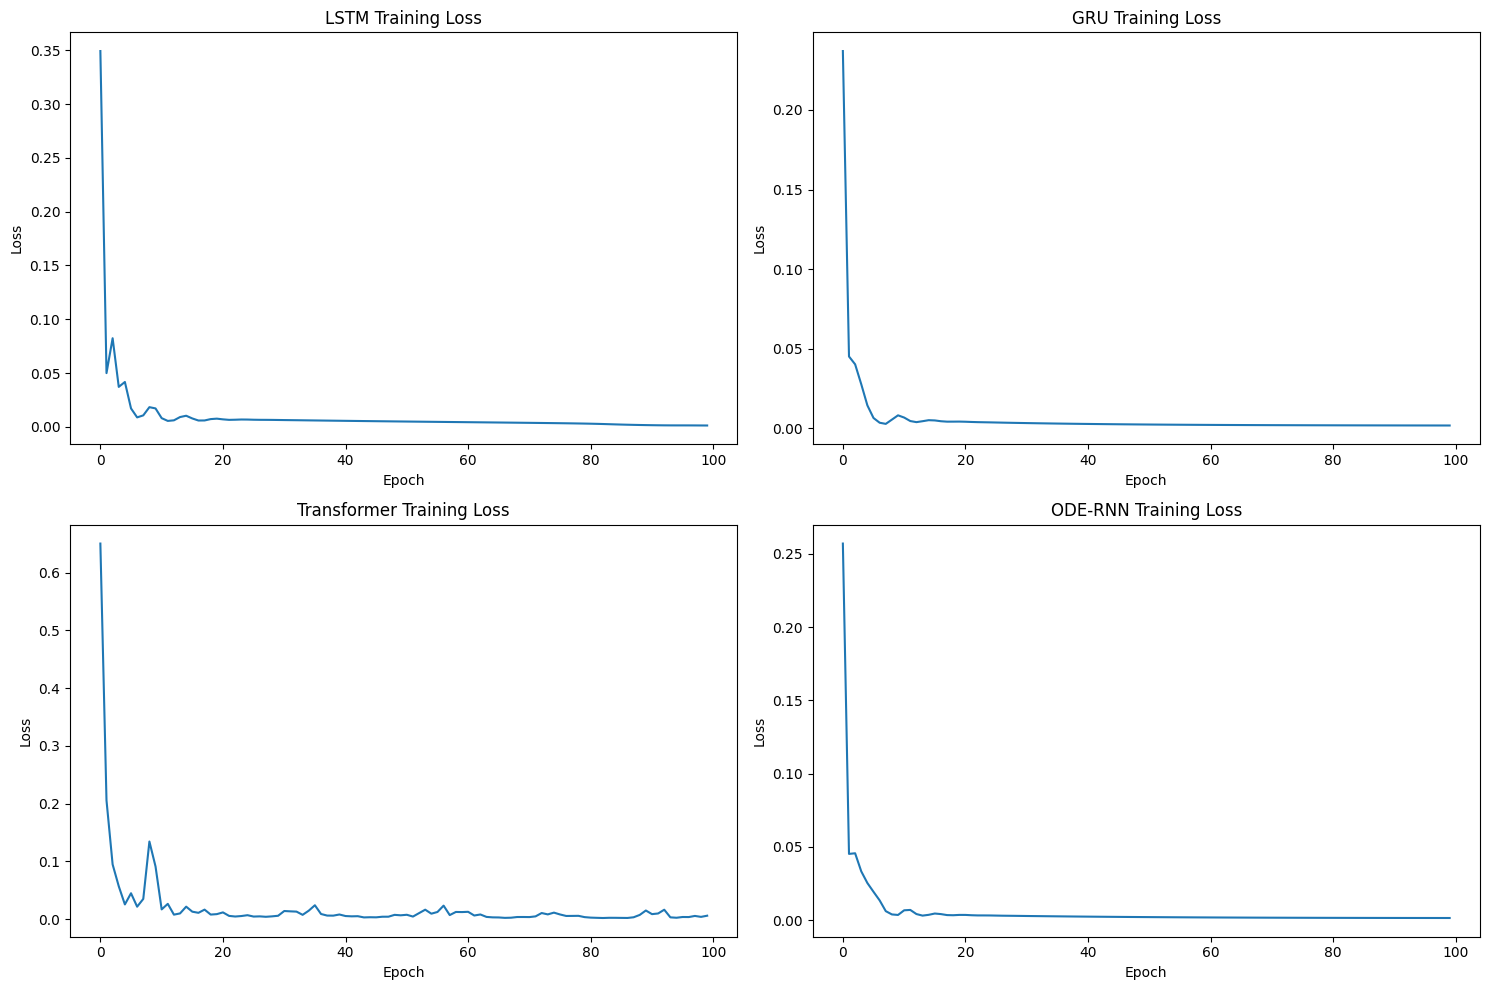

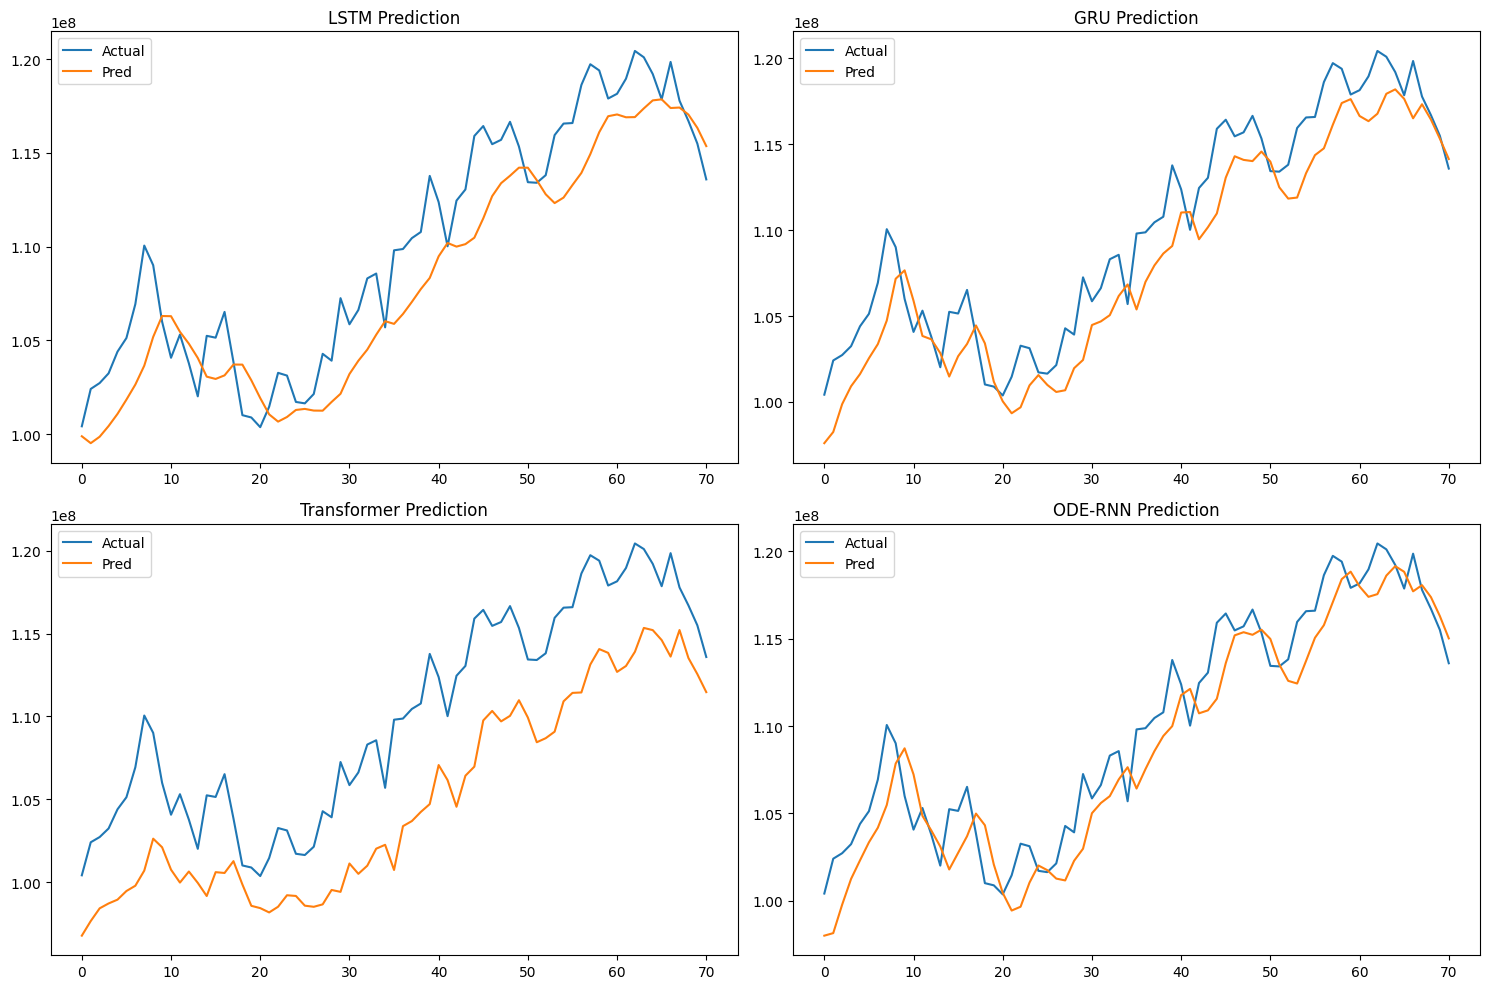

In [7]:
# 개별 학습 곡선 시각화
plt.figure(figsize=(15, 10))
for i, (name, res) in enumerate(results.items()):
    plt.subplot(2, 2, i+1)
    plt.plot(res["history"])
    plt.title(f"{name} Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
plt.tight_layout()
plt.show()

# 예측 결과 시각화 (개별)
plt.figure(figsize=(15, 10))
for i, (name, met) in enumerate(metrics.items()):
    plt.subplot(2, 2, i+1)
    plt.plot(met["actuals"], label="Actual")
    plt.plot(met["preds"], label="Pred")
    plt.title(f"{name} Prediction")
    plt.legend()
plt.tight_layout()
plt.show()

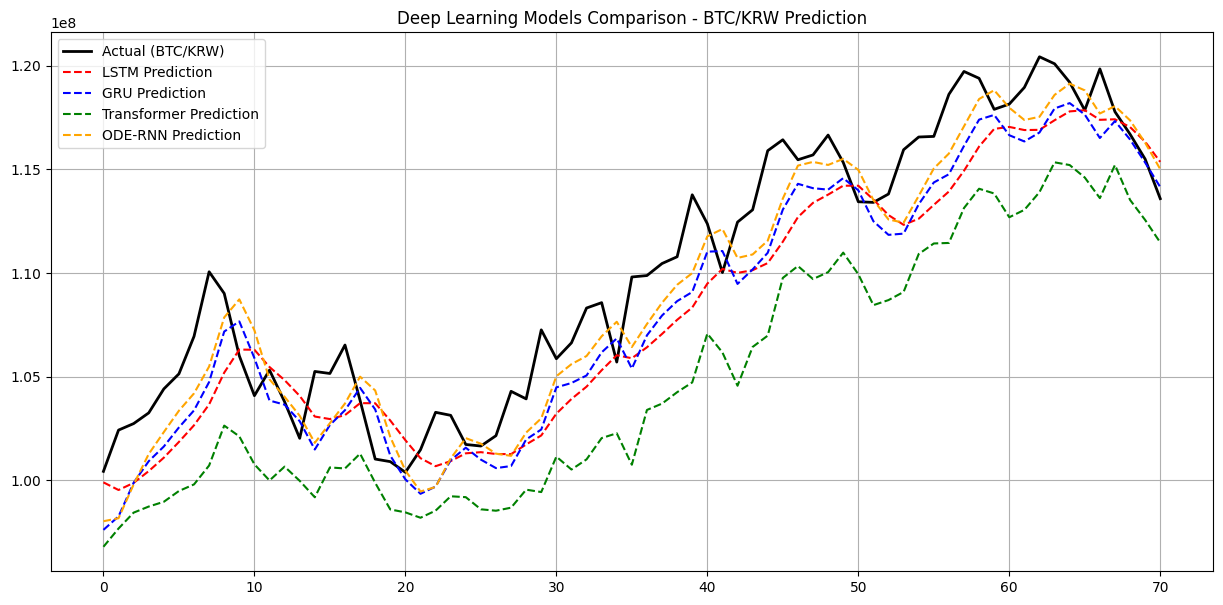

In [8]:
# 통합 캔들 차트 및 예측값 비교 (캔들 차트는 plotly 등으로 대체 가능하나 matplotlib으로 구현)
import matplotlib.dates as mdates

plt.figure(figsize=(15, 7))
actual_prices = metrics["LSTM"]["actuals"]
plt.plot(actual_prices, label="Actual (BTC/KRW)", color='black', linewidth=2)

colors = ['red', 'blue', 'green', 'orange']
for i, (name, met) in enumerate(metrics.items()):
    plt.plot(met["preds"], label=f"{name} Prediction", color=colors[i], linestyle='--')

plt.title("Deep Learning Models Comparison - BTC/KRW Prediction")
plt.legend()
plt.grid(True)
plt.show()

## 분석 결과 요약 보고서

### 1. 알고리즘별 성능 (MSE/MAE)
| 알고리즘 | MSE | MAE |
| :--- | :--- | :--- |
| LSTM | {mse_lstm} | {mae_lstm} |
| GRU | {mse_gru} | {mae_gru} |
| Transformer | {mse_tf} | {mae_tf} |
| ODE-RNN | {mse_ode} | {mae_ode} |

### 2. 종합 해석
- **LSTM/GRU**: 전통적인 순계열 모델로서 안정적인 수렴 성능을 보임. 비트코인과 같이 변동성이 큰 데이터에서도 추세를 비교적 잘 따라감.
- **Transformer**: 어텐션 메커니즘을 통해 데이터 간의 관계를 파악하려 하나, 단일 시계열(Univariate)에서는 데이터 양이 적을 경우 오버피팅 가능성이 있음.
- **ODE-RNN**: 연속적인 미분 방정식을 적용하여 상태 변화를 모델링함. 주가의 불규칙한 미세 변동을 포착하는 데 강점이 있을 수 있으나 연산량이 상대적으로 많음.

### 3. 향후 과제
- 다변량(Multivariate) 데이터(거래량, RSI, 뉴스 감성 등)를 추가하여 성능 고도화 필요.
- Informer 및 Autoformer와 같은 최신 SOTA 모델의 하이퍼파라미터 튜닝 수행 예정.